# Configuración

In [1]:
!pip install -q transformers datasets peft accelerate bitsandbytes seqeval evaluate
!pip install -U -q huggingface_hub
!pip install -q matplotlib
!pip install -q tabulate
!pip install -q -U spacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.3 MB/s eta 0:00:00


In [2]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification, AutoModelForSequenceClassification
from datasets import DatasetDict, Dataset
from evaluate import load
from peft import get_peft_model, LoraConfig, TaskType
import numpy as np
import pandas as pd
from seqeval.metrics import classification_report
import json
from pathlib import Path
import matplotlib.pyplot as plt
from huggingface_hub import login
from peft import PeftModel, PeftConfig
import torch
import re
import spacy
from spacy.tokens import Doc, Span
from spacy import displacy

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Ruta base del proyecto (puede estar en Drive o en disco local)
BASE_DIR = "/content/drive/MyDrive/Personal/Universidad/8° Semestre/PLN/Taller 2/BETO"
# Carpeta donde están los datos de entrada (.bio, etc.)
DATA_DIR = f"{BASE_DIR}/data"
# Carpeta donde se guardarán los resultados del entrenamiento (checkpoints, logs, etc.)
TRAINING_DIR = f"{BASE_DIR}/training"
# Carpeta donde se guardarán los modelos entrenados finales
MODEL_DIR = f"{BASE_DIR}/models"

# Entrenamiento

In [5]:
def parse_bio_file(path):
    sentences = []
    labels = []
    with open(path, encoding='utf-8') as f:
        words = []
        tags = []
        for line in f:
            line = line.strip()
            if not line:
                if words:
                    sentences.append(words)
                    labels.append(tags)
                    words = []
                    tags = []
                continue
            splits = line.split()
            if len(splits) >= 2:
                words.append(splits[0])
                tags.append(splits[-1])
    return {"tokens": sentences, "ner_tags": labels}


In [16]:
# Carga los datos de entrenamiento desde archivo .bio
train_data = parse_bio_file(f"{DATA_DIR}/training.bio")
# Carga los datos de validación desde archivo .bio (limpiado)
val_data = parse_bio_file(f"{DATA_DIR}/validation_cleaned.bio")
# Carga los datos de prueba desde archivo .bio (limpiado)
test_data = parse_bio_file(f"{DATA_DIR}/testing_cleaned.bio")

# Crea un objeto DatasetDict con las tres particiones: train, validation y test
dataset = DatasetDict({
    "train": Dataset.from_dict(train_data),
    "validation": Dataset.from_dict(val_data),
    "test": Dataset.from_dict(test_data)
})

In [17]:
# Extrae la lista de etiquetas únicas (sin repetir) presentes en los datos de entrenamiento
label_names = list(set(tag for doc in train_data["ner_tags"] for tag in doc))
print(label_names)

['B-GLEASON', 'B-TRATAMIENTO', 'I-CIRUGIA', 'B-CIRUGIA', 'I-EDAD', 'I-CANCER', 'B-FECHA', 'B-CANCER', 'I-BIOMARCADOR', 'B-MEDICAMENTO', 'I-GLEASON', 'B-EDAD', 'B-DOSIS', 'I-DOSIS', 'I-FECHA', 'B-TNM', 'O', 'I-MEDICAMENTO', 'I-TNM', 'B-BIOMARCADOR', 'I-TRATAMIENTO']


In [18]:
# Obtiene todas las etiquetas únicas en el conjunto de entrenamiento y las ordena alfabéticamente
unique_labels = sorted({tag for doc in dataset["train"]["ner_tags"] for tag in doc})
# Crea un diccionario que asigna un ID entero a cada etiqueta (label -> id)
label2id = {l: i for i, l in enumerate(unique_labels)}
# Crea el diccionario inverso para convertir de ID a etiqueta (id -> label)
id2label = {i: l for l, i in label2id.items()}

# Función que codifica las etiquetas de texto en IDs numéricos; si no encuentra la etiqueta, asigna -100
def encode_tags(example):
    return {
        "ner_tags": [label2id[tag] if tag in label2id else -100 for tag in example["ner_tags"]]
    }

# Aplica la función de codificación a todo el dataset
dataset = dataset.map(encode_tags)

Map:   0%|          | 0/3106 [00:00<?, ? examples/s]

Map:   0%|          | 0/929 [00:00<?, ? examples/s]

Map:   0%|          | 0/991 [00:00<?, ? examples/s]

In [19]:
print(id2label)

{0: 'B-BIOMARCADOR', 1: 'B-CANCER', 2: 'B-CIRUGIA', 3: 'B-DOSIS', 4: 'B-EDAD', 5: 'B-FECHA', 6: 'B-GLEASON', 7: 'B-MEDICAMENTO', 8: 'B-TNM', 9: 'B-TRATAMIENTO', 10: 'I-BIOMARCADOR', 11: 'I-CANCER', 12: 'I-CIRUGIA', 13: 'I-DOSIS', 14: 'I-EDAD', 15: 'I-FECHA', 16: 'I-GLEASON', 17: 'I-MEDICAMENTO', 18: 'I-TNM', 19: 'I-TRATAMIENTO', 20: 'O'}


In [20]:
# Alinea las etiquetas originales con los subtokens generados por el tokenizer
# Asigna -100 a los tokens especiales o subwords adicionales que no deben ser evaluados

def align_labels_with_tokens(labels, word_ids):
    new_labels = []
    current_word = None

    for word_id in word_ids:
        # Si es un nuevo token de palabra, tomar su etiqueta original
        if word_id != current_word:
            current_word = word_id
            label = -100 if word_id is None else labels[word_id]
            new_labels.append(label)
        # Si es un token especial (None), ignorarlo
        elif word_id is None:
            new_labels.append(-100)
        # Si es un subtoken de una palabra ya procesada
        else:
            label = labels[word_id]
            # Si la etiqueta original es impar (tipo B-), convertirla a par (tipo I-)
            if label % 2 == 1:
                label += 1
            new_labels.append(label)
    return new_labels

In [21]:
# Nombre del modelo base preentrenado (BETO en español, cased)
model_name = "dccuchile/bert-base-spanish-wwm-cased"

# Carga el tokenizer correspondiente al modelo
tokenizer = AutoTokenizer.from_pretrained(model_name, framework="pytorch")

# Función que tokeniza los ejemplos y alinea las etiquetas con los subtokens generados
def tokenize_and_align_labels(examples):
    # Tokeniza las secuencias de tokens manteniendo la separación por palabra
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
    )

    # Alinea las etiquetas reales con los tokens generados
    all_labels = examples["ner_tags"]
    new_labels = []
    for i, labels in enumerate(all_labels):
        word_ids = tokenized_inputs.word_ids(i)  # Mapea los subtokens a sus palabras originales
        new_labels.append(align_labels_with_tokens(labels, word_ids))

    # Asigna las etiquetas alineadas al input tokenizado
    tokenized_inputs["labels"] = new_labels
    return tokenized_inputs

# Aplica la función de tokenización y alineación a todo el dataset, en batch
# Elimina las columnas originales ("tokens", "ner_tags") ya que se reemplazan por la salida tokenizada
tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset["train"].column_names
)

Map:   0%|          | 0/3106 [00:00<?, ? examples/s]

Map:   0%|          | 0/929 [00:00<?, ? examples/s]

Map:   0%|          | 0/991 [00:00<?, ? examples/s]

In [ ]:
# Crea un data collator que agrega padding dinámico para tareas de clasificación de tokens (NER)
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

In [ ]:
# Toma los primeros 2 ejemplos del dataset tokenizado de entrenamiento
# y aplica el data collator para agruparlos en un batch con padding dinámico
batch = data_collator([tokenized_dataset["train"][i] for i in range(2)])

# Accede a las etiquetas del batch ya alineadas y con padding aplicado
batch["labels"]

tensor([[-100,   20,   20,   20,    4,    4,   14,   20,   20,   20,   20,   20,
           20,   20,   20, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100],
        [-100,   20,   20,   20,   20,   20,   20,   20,   20,   20,   20,   20,
      

In [22]:
import pandas as pd

def inspect_alignment(split="train", idx=0, max_rows=None):
    """
    Muestra:
      1) tabla palabra-nivel (word, word_label_id, word_label_str)
      2) tabla token-nivel (tok_idx, token, word_id, label_id, label_str)
    """
    # 0) mapping: usa el del modelo si existe; si no, el diccionario local
    id2lbl = None
    try:
        id2lbl = trainer.model.config.id2label
    except Exception:
        pass
    if id2lbl is None:
        id2lbl = id2label  # el que definiste tú
    # asegúrate de que las claves sean int
    id2lbl = {int(k): v for k, v in id2lbl.items()}

    # 1) palabra-nivel (del dataset crudo, ya con ner_tags en IDs)
    words = dataset[split]["tokens"][idx]
    word_lab_ids = dataset[split]["ner_tags"][idx]
    word_lab_txt = [("IGN" if i == -100 else id2lbl[int(i)]) for i in word_lab_ids]
    df_words = pd.DataFrame({
        "word_idx": list(range(len(words))),
        "word": words,
        "word_label_id": word_lab_ids,
        "word_label_str": word_lab_txt,
    })

    # 2) token-nivel (del dataset tokenizado + word_ids recomputados)
    ex_tok = tokenized_dataset[split][idx]
    input_ids = ex_tok["input_ids"]
    tok_lab_ids = ex_tok["labels"]            # lo que realmente se entrena
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    # recomputa word_ids con las MISMAS palabras (debe calzar)
    enc = tokenizer(words, is_split_into_words=True, truncation=True)
    word_ids = enc.word_ids(0)

    # sanity quick check
    assert len(tokens) == len(tok_lab_ids) == len(word_ids), "Longitudes no coinciden; revisa truncation/opciones."

    tok_lab_txt = [("IGN" if i == -100 else id2lbl[int(i)]) for i in tok_lab_ids]
    df_tokens = pd.DataFrame({
        "tok_idx": list(range(len(tokens))),
        "token": tokens,
        "word_id": word_ids,
        "label_id": tok_lab_ids,
        "label_str": tok_lab_txt,
    })

    # filtros/preview opcionales
    if max_rows is not None:
        df_words = df_words.head(max_rows)
        df_tokens = df_tokens.head(max_rows)

    print(f"[{split}] ejemplo #{idx}")
    print("\n— Palabra-nivel —")
    display(df_words)

    print("\n— Token-nivel (lo que ve el modelo) —")
    display(df_tokens)

# Ejemplos:
inspect_alignment("train", idx=0, max_rows=80)
# inspect_alignment("validation", idx=3)
# inspect_alignment("test", idx=1)


[train] ejemplo #0

— Palabra-nivel —


,word_idx,word,word_label_id,word_label_str
0,0,Paciente,20,O
1,1,de,20,O
2,2,72,4,B-EDAD
3,3,años,14,I-EDAD
4,4,",",20,O
5,5,con,20,O
6,6,antecedentes,20,O
7,7,médicos,20,O
8,8,de,20,O
9,9,HTA,20,O



— Token-nivel (lo que ve el modelo) —


,tok_idx,token,word_id,label_id,label_str
0,0,[CLS],NaN,-100,IGN
1,1,Paci,0.0,20,O
2,2,##ente,0.0,20,O
3,3,de,1.0,20,O
4,4,7,2.0,4,B-EDAD
5,5,##2,2.0,4,B-EDAD
6,6,años,3.0,14,I-EDAD
7,7,",",4.0,20,O
8,8,con,5.0,20,O
9,9,antecedentes,6.0,20,O


In [ ]:
# Inicializa el modelo base para clasificación de tokens y lo adapta con PEFT (LoRA)
def model_init():
    # Carga el modelo preentrenado de clasificación de tokens con las etiquetas definidas
    model = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=len(label2id),     # Número total de etiquetas
        id2label=id2label,            # Mapea IDs a etiquetas de texto
        label2id=label2id,            # Mapea etiquetas de texto a IDs
        ignore_mismatched_sizes=True  # Ignora conflictos si cambia el tamaño de salida
    )

    # Configura LoRA (Low-Rank Adaptation) para fine-tuning eficiente
    peft_config = LoraConfig(
        task_type=TaskType.TOKEN_CLS,  # Tarea: clasificación de tokens (NER)
        r=8,                            # Rango del espacio proyectado
        lora_alpha=16,                 # Escalamiento de la actualización LoRA
        lora_dropout=0.1,              # Dropout aplicado a LoRA
        bias="none"                    # No entrena bias
    )

    # Aplica la configuración LoRA al modelo base
    model = get_peft_model(model, peft_config)

    return model

In [ ]:
# Lista de configuraciones de entrenamiento para experimentar con diferentes épocas y tamaños de batch
# Puedes activar más combinaciones descomentando las líneas correspondientes
models = [
    # {"epochs": 3, "batch_size": 4},
    # {"epochs": 3, "batch_size": 8},
    {"epochs": 3, "batch_size": 16},
    # {"epochs": 3, "batch_size": 32},
    {"epochs": 4, "batch_size": 4},
    # {"epochs": 4, "batch_size": 8},
    {"epochs": 4, "batch_size": 16},
    # {"epochs": 4, "batch_size": 32},
    {"epochs": 5, "batch_size": 4},
    # {"epochs": 5, "batch_size": 8},
    {"epochs": 5, "batch_size": 16},
    # {"epochs": 5, "batch_size": 32},
]

In [ ]:
# Carga la métrica de evaluación para NER
metric = load("seqeval")

# Calcula métricas de evaluación globales y por etiqueta para NER
def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)

    # Convierte etiquetas y predicciones de ID a texto, ignorando subwords (-100)
    true_labels = [[label_names[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [label_names[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    # Métricas globales con la librería `evaluate`
    report = metric.compute(predictions=true_predictions, references=true_labels)
    results = {
        "precision": report["overall_precision"],
        "recall": report["overall_recall"],
        "f1": report["overall_f1"],
        "accuracy": report["overall_accuracy"],
    }

    # Métricas por etiqueta con `seqeval`
    full_report = classification_report(true_labels, true_predictions, output_dict=True)
    for label, scores in full_report.items():
        if isinstance(scores, dict):  # evita incluir micro/macro avg
            results[f"{label}_precision"] = scores.get("precision", 0.0)
            results[f"{label}_recall"] = scores.get("recall", 0.0)
            results[f"{label}_f1"] = scores.get("f1-score", 0.0)

    return results

# Imprime en consola una tabla con métricas por etiqueta (precision, recall, f1-score)
def print_metrics_by_label(trainer, dataset, label_names):
    # Obtiene predicciones del modelo para el conjunto dado
    eval_preds = trainer.predict(dataset)
    logits, labels = eval_preds.predictions, eval_preds.label_ids
    predictions = np.argmax(logits, axis=-1)

    # Convierte etiquetas y predicciones de ID a texto
    true_labels = [
        [label_names[l] for l in label if l != -100]
        for label in labels
    ]
    true_predictions = [
        [label_names[p] for (p, l) in zip(pred, label) if l != -100]
        for pred, label in zip(predictions, labels)
    ]

    # Genera reporte por etiqueta con `seqeval`
    report = classification_report(true_labels, true_predictions, output_dict=True)
    df = pd.DataFrame(report).transpose()

    # Muestra solo columnas relevantes
    df = df[["precision", "recall", "f1-score", "support"]]

    print("\n📊 Métricas por etiqueta:")
    print(df.to_markdown())

In [ ]:
# Guarda el modelo entrenado, el tokenizer y los resultados de evaluación en disco
def save_model_hf(trainer, epochs, batch_size, eval_results):
    # Define la ruta donde se guardará el modelo, según época y tamaño de batch
    save_dir = Path(f"{MODEL_DIR}/_ep{epochs}_bs{batch_size}")
    save_dir.mkdir(parents=True, exist_ok=True)  # Crea la carpeta si no existe

    # Guarda los pesos del modelo y el tokenizer en la ruta especificada
    trainer.save_model(str(save_dir))
    trainer.tokenizer.save_pretrained(str(save_dir))

    # Guarda los resultados de evaluación como un archivo JSON
    eval_path = save_dir / "eval_results.json"
    with open(eval_path, "w") as f:
        json.dump(eval_results, f, indent=4)

In [ ]:
def plot_trainer_history(log_history):
    train_loss = []
    eval_loss = []
    epochs = []

    for log in log_history:
        epoch = log.get("epoch")
        if epoch is None:
            continue

        if "loss" in log:
            train_loss.append((epoch, log["loss"]))

        if "eval_loss" in log:
            eval_loss.append((epoch, log["eval_loss"]))

    if not train_loss and not eval_loss:
        print("⚠️ No se encontraron valores de loss para entrenamiento o validación.")
        return

    plt.figure(figsize=(8, 5))

    if train_loss:
        x_train, y_train = zip(*train_loss)
        plt.plot(x_train, y_train, label="Train Loss", marker="o")

    if eval_loss:
        x_eval, y_eval = zip(*eval_loss)
        plt.plot(x_eval, y_eval, label="Eval Loss", marker="x")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Comparación de pérdida: Entrenamiento vs Evaluación")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Some weights of BertForTokenClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-32-394e560dda7f>:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForTokenClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Biomarcador Precision,Biomarcador Recall,Biomarcador F1,Cancer Precision,Cancer Recall,Cancer F1,Cirugia Precision,Cirugia Recall,Cirugia F1,Dosis Precision,Dosis Recall,Dosis F1,Edad Precision,Edad Recall,Edad F1,Fecha Precision,Fecha Recall,Fecha F1,Gleason Precision,Gleason Recall,Gleason F1,Medicamento Precision,Medicamento Recall,Medicamento F1,Tnm Precision,Tnm Recall,Tnm F1,Tratamiento Precision,Tratamiento Recall,Tratamiento F1,Micro avg Precision,Micro avg Recall,Micro avg F1,Macro avg Precision,Macro avg Recall,Macro avg F1,Weighted avg Precision,Weighted avg Recall,Weighted avg F1
1,0.683100,0.223225,0.934344,0.939925,0.937126,0.936335,0.949717,0.975806,0.962585,0.982890,0.779789,0.869638,0.865724,0.801964,0.832625,0.812352,0.826087,0.819162,0.904594,0.844884,0.873720,0.859729,0.753968,0.803383,0.884858,0.720154,0.794055,0.848000,0.854839,0.851406,0.775819,0.749392,0.762376,0.840522,0.843907,0.842211,0.934344,0.939925,0.937126,0.872420,0.815079,0.841116,0.933695,0.939925,0.935974
2,0.252200,0.144323,0.956914,0.956914,0.956914,0.955698,0.975546,0.973640,0.974592,0.979661,0.871795,0.922586,0.880328,0.878887,0.879607,0.844444,0.917874,0.879630,0.865031,0.930693,0.896661,0.906250,0.920635,0.913386,0.881266,0.857510,0.869226,0.869565,0.887097,0.878244,0.853598,0.836983,0.845209,0.859155,0.921450,0.889213,0.956914,0.956914,0.956914,0.891485,0.899656,0.894835,0.957494,0.956914,0.957019
3,0.189000,0.122631,0.962528,0.966362,0.964441,0.964362,0.977464,0.982937,0.980193,0.981544,0.882353,0.929309,0.899506,0.893617,0.896552,0.879908,0.920290,0.899646,0.907643,0.940594,0.923825,0.915663,0.904762,0.910180,0.914894,0.883184,0.898759,0.869048,0.883065,0.876000,0.845783,0.854015,0.849879,0.881226,0.926485,0.903289,0.962528,0.966362,0.964441,0.907268,0.907130,0.906763,0.962748,0.966362,0.964428


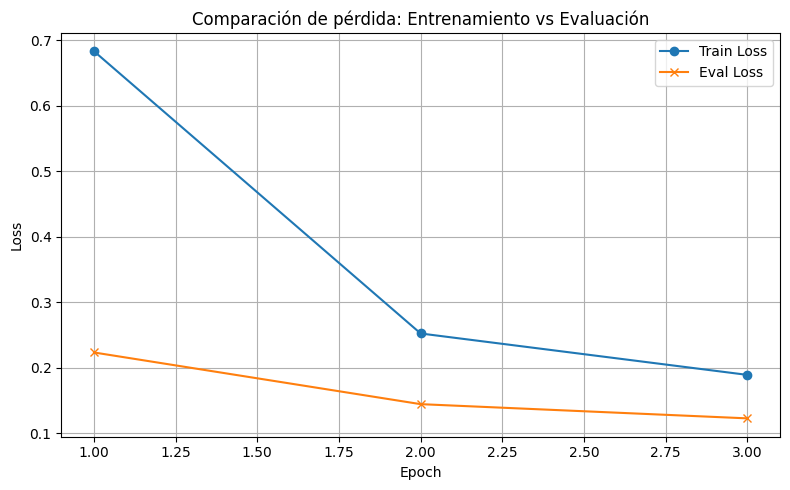


📊 Métricas por etiqueta:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| BIOMARCADOR  |    0.971502 | 0.983757 |   0.977591 |     23148 |
| CANCER       |    0.94016  | 0.878261 |   0.908157 |       805 |
| CIRUGIA      |    0.938053 | 0.911175 |   0.924419 |       698 |
| DOSIS        |    0.885668 | 0.874404 |   0.88     |       629 |
| EDAD         |    0.936675 | 0.926893 |   0.931759 |       383 |
| FECHA        |    0.899736 | 0.881137 |   0.890339 |       387 |
| GLEASON      |    0.918067 | 0.851022 |   0.883274 |      1027 |
| MEDICAMENTO  |    0.891117 | 0.922849 |   0.906706 |       337 |
| TNM          |    0.857143 | 0.855469 |   0.856305 |       512 |
| TRATAMIENTO  |    0.876404 | 0.906274 |   0.891089 |      1291 |
| micro avg    |    0.957749 | 0.963617 |   0.960674 |     29217 |
| macro avg    |    0.911453 | 0.899124 |   0.904964 |     29217 |
| weighted avg |    0.957573 | 0.963


📊 Métricas por etiqueta:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| BIOMARCADOR  |    0.977464 | 0.982937 |   0.980193 |     18930 |
| CANCER       |    0.981544 | 0.882353 |   0.929309 |       663 |
| CIRUGIA      |    0.899506 | 0.893617 |   0.896552 |       611 |
| DOSIS        |    0.879908 | 0.92029  |   0.899646 |       414 |
| EDAD         |    0.907643 | 0.940594 |   0.923825 |       303 |
| FECHA        |    0.915663 | 0.904762 |   0.91018  |       252 |
| GLEASON      |    0.914894 | 0.883184 |   0.898759 |       779 |
| MEDICAMENTO  |    0.869048 | 0.883065 |   0.876    |       248 |
| TNM          |    0.845783 | 0.854015 |   0.849879 |       411 |
| TRATAMIENTO  |    0.881226 | 0.926485 |   0.903289 |       993 |
| micro avg    |    0.962528 | 0.966362 |   0.964441 |     23604 |
| macro avg    |    0.907268 | 0.90713  |   0.906763 |     23604 |
| weighted avg |    0.962748 | 0.966

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Some weights of BertForTokenClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-32-394e560dda7f>:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForTokenClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. 

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Biomarcador Precision,Biomarcador Recall,Biomarcador F1,Cancer Precision,Cancer Recall,Cancer F1,Cirugia Precision,Cirugia Recall,Cirugia F1,Dosis Precision,Dosis Recall,Dosis F1,Edad Precision,Edad Recall,Edad F1,Fecha Precision,Fecha Recall,Fecha F1,Gleason Precision,Gleason Recall,Gleason F1,Medicamento Precision,Medicamento Recall,Medicamento F1,Tnm Precision,Tnm Recall,Tnm F1,Tratamiento Precision,Tratamiento Recall,Tratamiento F1,Micro avg Precision,Micro avg Recall,Micro avg F1,Macro avg Precision,Macro avg Recall,Macro avg F1,Weighted avg Precision,Weighted avg Recall,Weighted avg F1
1,0.670100,0.223104,0.933854,0.937256,0.935552,0.935204,0.950916,0.973270,0.961963,0.985263,0.705882,0.822496,0.847636,0.792144,0.818951,0.865823,0.826087,0.845488,0.888087,0.811881,0.848276,0.885593,0.829365,0.856557,0.877023,0.695764,0.775948,0.797753,0.858871,0.827184,0.805825,0.807786,0.806804,0.811090,0.869084,0.839086,0.933854,0.937256,0.935552,0.871501,0.817013,0.840275,0.933754,0.937256,0.934290
2,0.238000,0.132961,0.959042,0.960261,0.959651,0.958975,0.978283,0.975647,0.976963,0.972650,0.858220,0.911859,0.889073,0.878887,0.883951,0.823529,0.913043,0.865979,0.874233,0.940594,0.906200,0.933333,0.944444,0.938856,0.875159,0.881900,0.878517,0.893281,0.911290,0.902196,0.885000,0.861314,0.872996,0.848346,0.929507,0.887074,0.959042,0.960261,0.959651,0.897289,0.909485,0.902459,0.959898,0.960261,0.959839
3,0.168400,0.103325,0.966710,0.969454,0.968080,0.968280,0.984416,0.981088,0.982749,0.972039,0.891403,0.929976,0.897059,0.898527,0.897792,0.843478,0.937198,0.887872,0.909938,0.966997,0.937600,0.923077,0.952381,0.937500,0.888752,0.922978,0.905542,0.911647,0.915323,0.913481,0.852113,0.883212,0.867384,0.888574,0.947633,0.917154,0.966710,0.969454,0.968080,0.907109,0.929674,0.917705,0.967467,0.969454,0.968297
4,0.142600,0.094773,0.970665,0.972886,0.971774,0.971332,0.984928,0.983835,0.984381,0.981818,0.895928,0.936909,0.918167,0.918167,0.918167,0.880090,0.939614,0.908879,0.936102,0.966997,0.951299,0.941634,0.960317,0.950884,0.918367,0.924262,0.921305,0.901186,0.919355,0.910180,0.858491,0.885645,0.871856,0.895283,0.955690,0.924501,0.970665,0.972886,0.971774,0.921607,0.934981,0.927836,0.971135,0.972886,0.971887


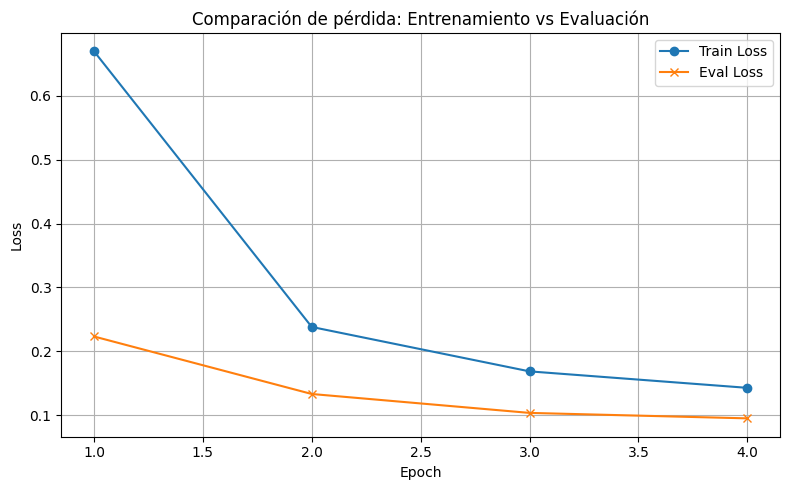


📊 Métricas por etiqueta:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| BIOMARCADOR  |    0.98178  | 0.984664 |   0.98322  |     23148 |
| CANCER       |    0.972789 | 0.888199 |   0.928571 |       805 |
| CIRUGIA      |    0.939306 | 0.931232 |   0.935252 |       698 |
| DOSIS        |    0.895639 | 0.914149 |   0.904799 |       629 |
| EDAD         |    0.94898  | 0.971279 |   0.96     |       383 |
| FECHA        |    0.94026  | 0.935401 |   0.937824 |       387 |
| GLEASON      |    0.924378 | 0.904576 |   0.91437  |      1027 |
| MEDICAMENTO  |    0.941691 | 0.958457 |   0.95     |       337 |
| TNM          |    0.880455 | 0.90625  |   0.893167 |       512 |
| TRATAMIENTO  |    0.896171 | 0.94268  |   0.918837 |      1291 |
| micro avg    |    0.969449 | 0.972037 |   0.970741 |     29217 |
| macro avg    |    0.932145 | 0.933689 |   0.932604 |     29217 |
| weighted avg |    0.969644 | 0.972


📊 Métricas por etiqueta:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| BIOMARCADOR  |    0.984928 | 0.983835 |   0.984381 |     18930 |
| CANCER       |    0.981818 | 0.895928 |   0.936909 |       663 |
| CIRUGIA      |    0.918167 | 0.918167 |   0.918167 |       611 |
| DOSIS        |    0.88009  | 0.939614 |   0.908879 |       414 |
| EDAD         |    0.936102 | 0.966997 |   0.951299 |       303 |
| FECHA        |    0.941634 | 0.960317 |   0.950884 |       252 |
| GLEASON      |    0.918367 | 0.924262 |   0.921305 |       779 |
| MEDICAMENTO  |    0.901186 | 0.919355 |   0.91018  |       248 |
| TNM          |    0.858491 | 0.885645 |   0.871856 |       411 |
| TRATAMIENTO  |    0.895283 | 0.95569  |   0.924501 |       993 |
| micro avg    |    0.970665 | 0.972886 |   0.971774 |     23604 |
| macro avg    |    0.921607 | 0.934981 |   0.927836 |     23604 |
| weighted avg |    0.971135 | 0.972

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Some weights of BertForTokenClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-32-394e560dda7f>:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForTokenClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. 

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Biomarcador Precision,Biomarcador Recall,Biomarcador F1,Cancer Precision,Cancer Recall,Cancer F1,Cirugia Precision,Cirugia Recall,Cirugia F1,Dosis Precision,Dosis Recall,Dosis F1,Edad Precision,Edad Recall,Edad F1,Fecha Precision,Fecha Recall,Fecha F1,Gleason Precision,Gleason Recall,Gleason F1,Medicamento Precision,Medicamento Recall,Medicamento F1,Tnm Precision,Tnm Recall,Tnm F1,Tratamiento Precision,Tratamiento Recall,Tratamiento F1,Micro avg Precision,Micro avg Recall,Micro avg F1,Macro avg Precision,Macro avg Recall,Macro avg F1,Weighted avg Precision,Weighted avg Recall,Weighted avg F1
1,0.660400,0.227328,0.931747,0.937511,0.934620,0.934225,0.945766,0.976492,0.960884,0.976424,0.749623,0.848123,0.870337,0.801964,0.834753,0.833735,0.835749,0.834741,0.924188,0.844884,0.882759,0.833333,0.734127,0.780591,0.900697,0.663671,0.764228,0.792157,0.814516,0.803181,0.825352,0.712895,0.765013,0.828986,0.864048,0.846154,0.931747,0.937511,0.934620,0.873098,0.799797,0.832042,0.931122,0.937511,0.932927
2,0.242700,0.132266,0.959414,0.960430,0.959922,0.960105,0.979109,0.975489,0.977296,0.981324,0.871795,0.923323,0.892157,0.893617,0.892886,0.827957,0.929952,0.875995,0.854599,0.950495,0.900000,0.913043,0.916667,0.914851,0.875159,0.881900,0.878517,0.874510,0.899194,0.886680,0.851582,0.851582,0.851582,0.862524,0.922457,0.891484,0.959414,0.960430,0.959922,0.891196,0.909315,0.899261,0.960311,0.960430,0.960148
3,0.169700,0.103031,0.967963,0.971530,0.969743,0.970089,0.983357,0.983201,0.983279,0.978405,0.888386,0.931225,0.920583,0.929624,0.925081,0.857768,0.946860,0.900115,0.918750,0.970297,0.943820,0.911197,0.936508,0.923679,0.897277,0.930680,0.913674,0.907258,0.907258,0.907258,0.872236,0.863747,0.867971,0.894837,0.942598,0.918097,0.967963,0.971530,0.969743,0.914167,0.929916,0.921420,0.968491,0.971530,0.969863
4,0.142400,0.094312,0.971914,0.973479,0.972696,0.972387,0.984785,0.984733,0.984759,0.978723,0.901961,0.938776,0.929160,0.923077,0.926108,0.892449,0.942029,0.916569,0.942308,0.970297,0.956098,0.921875,0.936508,0.929134,0.918679,0.928113,0.923372,0.904000,0.911290,0.907631,0.881643,0.888078,0.884848,0.905679,0.947633,0.926181,0.971914,0.973479,0.972696,0.925930,0.933372,0.929348,0.972184,0.973479,0.972751


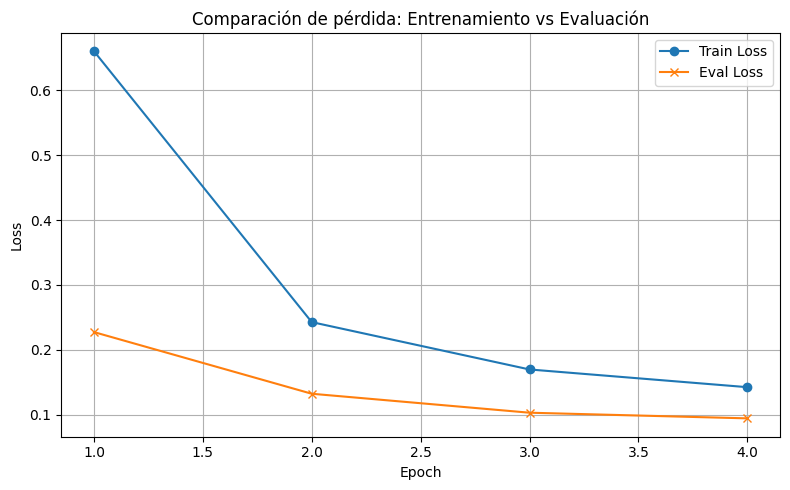


📊 Métricas por etiqueta:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| BIOMARCADOR  |    0.980699 | 0.985571 |   0.983129 |     23148 |
| CANCER       |    0.95756  | 0.896894 |   0.926235 |       805 |
| CIRUGIA      |    0.95481  | 0.938395 |   0.946532 |       698 |
| DOSIS        |    0.890796 | 0.90779  |   0.899213 |       629 |
| EDAD         |    0.953003 | 0.953003 |   0.953003 |       383 |
| FECHA        |    0.915816 | 0.927649 |   0.921694 |       387 |
| GLEASON      |    0.918627 | 0.912366 |   0.915486 |      1027 |
| MEDICAMENTO  |    0.947214 | 0.958457 |   0.952802 |       337 |
| TNM          |    0.891089 | 0.878906 |   0.884956 |       512 |
| TRATAMIENTO  |    0.905303 | 0.925639 |   0.915358 |      1291 |
| micro avg    |    0.968811 | 0.971729 |   0.970268 |     29217 |
| macro avg    |    0.931492 | 0.928467 |   0.929841 |     29217 |
| weighted avg |    0.968815 | 0.971


📊 Métricas por etiqueta:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| BIOMARCADOR  |    0.984785 | 0.984733 |   0.984759 |     18930 |
| CANCER       |    0.978723 | 0.901961 |   0.938776 |       663 |
| CIRUGIA      |    0.92916  | 0.923077 |   0.926108 |       611 |
| DOSIS        |    0.892449 | 0.942029 |   0.916569 |       414 |
| EDAD         |    0.942308 | 0.970297 |   0.956098 |       303 |
| FECHA        |    0.921875 | 0.936508 |   0.929134 |       252 |
| GLEASON      |    0.918679 | 0.928113 |   0.923372 |       779 |
| MEDICAMENTO  |    0.904    | 0.91129  |   0.907631 |       248 |
| TNM          |    0.881643 | 0.888078 |   0.884848 |       411 |
| TRATAMIENTO  |    0.905679 | 0.947633 |   0.926181 |       993 |
| micro avg    |    0.971914 | 0.973479 |   0.972696 |     23604 |
| macro avg    |    0.92593  | 0.933372 |   0.929348 |     23604 |
| weighted avg |    0.972184 | 0.973

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Some weights of BertForTokenClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-32-394e560dda7f>:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForTokenClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. 

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Biomarcador Precision,Biomarcador Recall,Biomarcador F1,Cancer Precision,Cancer Recall,Cancer F1,Cirugia Precision,Cirugia Recall,Cirugia F1,Dosis Precision,Dosis Recall,Dosis F1,Edad Precision,Edad Recall,Edad F1,Fecha Precision,Fecha Recall,Fecha F1,Gleason Precision,Gleason Recall,Gleason F1,Medicamento Precision,Medicamento Recall,Medicamento F1,Tnm Precision,Tnm Recall,Tnm F1,Tratamiento Precision,Tratamiento Recall,Tratamiento F1,Micro avg Precision,Micro avg Recall,Micro avg F1,Macro avg Precision,Macro avg Recall,Macro avg F1,Weighted avg Precision,Weighted avg Recall,Weighted avg F1
1,0.657500,0.225631,0.931380,0.938443,0.934898,0.934602,0.944473,0.977602,0.960752,0.975000,0.764706,0.857143,0.873214,0.800327,0.835184,0.824096,0.826087,0.825090,0.923913,0.841584,0.880829,0.837104,0.734127,0.782241,0.906028,0.655969,0.760983,0.811024,0.830645,0.820717,0.830028,0.712895,0.767016,0.835283,0.863041,0.848935,0.931380,0.938443,0.934898,0.876016,0.800698,0.833889,0.930707,0.938443,0.933138
2,0.237100,0.125615,0.960542,0.963269,0.961904,0.962253,0.979367,0.977919,0.978642,0.981387,0.874811,0.925040,0.894481,0.901800,0.898126,0.833333,0.929952,0.878995,0.863095,0.957096,0.907668,0.927711,0.916667,0.922156,0.877707,0.884467,0.881074,0.877953,0.899194,0.888446,0.849879,0.854015,0.851942,0.870179,0.931521,0.899805,0.960542,0.963269,0.961904,0.895509,0.912744,0.903189,0.961353,0.963269,0.962100
3,0.161600,0.095096,0.970643,0.974920,0.972776,0.972801,0.983005,0.986952,0.984975,0.983250,0.885370,0.931746,0.933007,0.934534,0.933769,0.872483,0.942029,0.905923,0.933333,0.970297,0.951456,0.925781,0.940476,0.933071,0.904348,0.934531,0.919192,0.907258,0.907258,0.907258,0.896465,0.863747,0.879802,0.918129,0.948640,0.933135,0.970643,0.974920,0.972776,0.925706,0.931383,0.928033,0.970903,0.974920,0.972783
4,0.130700,0.085804,0.975256,0.976826,0.976040,0.975589,0.987663,0.985367,0.986514,0.983793,0.915535,0.948438,0.934641,0.936170,0.935405,0.886161,0.958937,0.921114,0.954545,0.970297,0.962357,0.930502,0.956349,0.943249,0.920200,0.947368,0.933586,0.908730,0.923387,0.916000,0.884337,0.892944,0.888620,0.919463,0.965760,0.942043,0.975256,0.976826,0.976040,0.931003,0.945212,0.937732,0.975642,0.976826,0.976139
5,0.116500,0.079050,0.977339,0.979368,0.978352,0.978113,0.988472,0.987427,0.987949,0.980800,0.924585,0.951863,0.941080,0.941080,0.941080,0.906606,0.961353,0.933177,0.951613,0.973597,0.962480,0.933852,0.952381,0.943026,0.934591,0.953787,0.944091,0.919355,0.919355,0.919355,0.876190,0.895377,0.885680,0.929672,0.971803,0.950271,0.977339,0.979368,0.978352,0.936223,0.948075,0.941897,0.977604,0.979368,0.978421


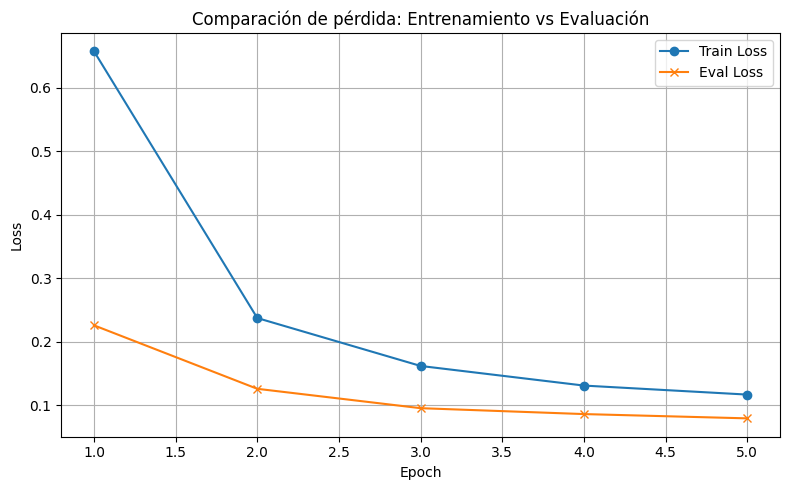


📊 Métricas por etiqueta:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| BIOMARCADOR  |    0.985001 | 0.987299 |   0.986149 |     23148 |
| CANCER       |    0.973822 | 0.924224 |   0.948375 |       805 |
| CIRUGIA      |    0.955524 | 0.954155 |   0.954839 |       698 |
| DOSIS        |    0.9      | 0.915739 |   0.907801 |       629 |
| EDAD         |    0.953368 | 0.960836 |   0.957087 |       383 |
| FECHA        |    0.928753 | 0.943152 |   0.935897 |       387 |
| GLEASON      |    0.917939 | 0.936709 |   0.927229 |      1027 |
| MEDICAMENTO  |    0.964497 | 0.967359 |   0.965926 |       337 |
| TNM          |    0.896484 | 0.896484 |   0.896484 |       512 |
| TRATAMIENTO  |    0.938215 | 0.95275  |   0.945427 |      1291 |
| micro avg    |    0.974702 | 0.977171 |   0.975935 |     29217 |
| macro avg    |    0.94136  | 0.943871 |   0.942521 |     29217 |
| weighted avg |    0.974787 | 0.977


📊 Métricas por etiqueta:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| BIOMARCADOR  |    0.988472 | 0.987427 |   0.987949 |     18930 |
| CANCER       |    0.9808   | 0.924585 |   0.951863 |       663 |
| CIRUGIA      |    0.94108  | 0.94108  |   0.94108  |       611 |
| DOSIS        |    0.906606 | 0.961353 |   0.933177 |       414 |
| EDAD         |    0.951613 | 0.973597 |   0.96248  |       303 |
| FECHA        |    0.933852 | 0.952381 |   0.943026 |       252 |
| GLEASON      |    0.934591 | 0.953787 |   0.944091 |       779 |
| MEDICAMENTO  |    0.919355 | 0.919355 |   0.919355 |       248 |
| TNM          |    0.87619  | 0.895377 |   0.88568  |       411 |
| TRATAMIENTO  |    0.929672 | 0.971803 |   0.950271 |       993 |
| micro avg    |    0.977339 | 0.979368 |   0.978352 |     23604 |
| macro avg    |    0.936223 | 0.948075 |   0.941897 |     23604 |
| weighted avg |    0.977604 | 0.979

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Some weights of BertForTokenClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-32-394e560dda7f>:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForTokenClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. 

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Biomarcador Precision,Biomarcador Recall,Biomarcador F1,Cancer Precision,Cancer Recall,Cancer F1,Cirugia Precision,Cirugia Recall,Cirugia F1,Dosis Precision,Dosis Recall,Dosis F1,Edad Precision,Edad Recall,Edad F1,Fecha Precision,Fecha Recall,Fecha F1,Gleason Precision,Gleason Recall,Gleason F1,Medicamento Precision,Medicamento Recall,Medicamento F1,Tnm Precision,Tnm Recall,Tnm F1,Tratamiento Precision,Tratamiento Recall,Tratamiento F1,Micro avg Precision,Micro avg Recall,Micro avg F1,Macro avg Precision,Macro avg Recall,Macro avg F1,Weighted avg Precision,Weighted avg Recall,Weighted avg F1
1,0.679200,0.229960,0.926171,0.938570,0.932329,0.931626,0.933601,0.984152,0.958210,0.991170,0.677225,0.804659,0.892045,0.770867,0.827041,0.859116,0.751208,0.801546,0.921260,0.772277,0.840215,0.855932,0.801587,0.827869,0.947070,0.643132,0.766055,0.845850,0.862903,0.854291,0.836066,0.744526,0.787645,0.849593,0.841893,0.845726,0.926171,0.938570,0.932329,0.893170,0.784977,0.831326,0.926138,0.938570,0.929712
2,0.233900,0.130091,0.960305,0.961362,0.960833,0.960482,0.979990,0.975383,0.977681,0.984402,0.856712,0.916129,0.904376,0.913257,0.908795,0.795132,0.946860,0.864388,0.874618,0.943894,0.907937,0.924303,0.920635,0.922465,0.889029,0.905006,0.896947,0.872000,0.879032,0.875502,0.840194,0.844282,0.842233,0.863296,0.928499,0.894711,0.960305,0.961362,0.960833,0.892734,0.911356,0.900679,0.961488,0.961362,0.961110
3,0.163000,0.099143,0.969450,0.971996,0.970721,0.970541,0.984502,0.983254,0.983878,0.971619,0.877828,0.922345,0.922705,0.937807,0.930195,0.863931,0.966184,0.912201,0.929712,0.960396,0.944805,0.910156,0.924603,0.917323,0.899876,0.934531,0.916877,0.910931,0.907258,0.909091,0.880893,0.863747,0.872236,0.898951,0.949648,0.923604,0.969450,0.971996,0.970721,0.917328,0.930526,0.923255,0.969960,0.971996,0.970814
4,0.133500,0.084315,0.973735,0.975386,0.974560,0.974421,0.987233,0.984469,0.985849,0.982026,0.906486,0.942745,0.943182,0.950900,0.947025,0.875546,0.968599,0.919725,0.966887,0.963696,0.965289,0.915058,0.940476,0.927593,0.919699,0.940950,0.930203,0.923077,0.919355,0.921212,0.850816,0.888078,0.869048,0.906399,0.955690,0.930392,0.973735,0.975386,0.974560,0.926992,0.941870,0.933908,0.974277,0.975386,0.974705
5,0.118100,0.079228,0.974714,0.976572,0.975642,0.975400,0.988022,0.984786,0.986401,0.974194,0.911011,0.941543,0.941842,0.954173,0.947967,0.887168,0.968599,0.926097,0.960912,0.973597,0.967213,0.930233,0.952381,0.941176,0.916563,0.944801,0.930468,0.931174,0.927419,0.929293,0.853488,0.892944,0.872771,0.911962,0.959718,0.935231,0.974714,0.976572,0.975642,0.929556,0.946943,0.937816,0.975206,0.976572,0.975782


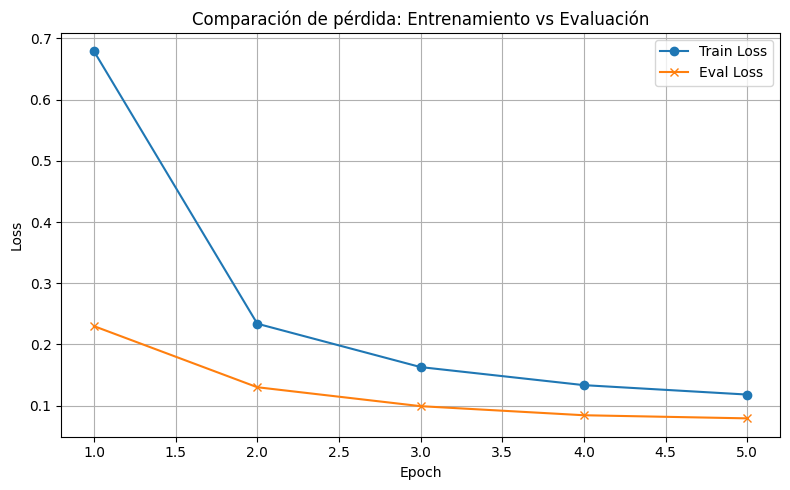


📊 Métricas por etiqueta:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| BIOMARCADOR  |    0.984381 | 0.985614 |   0.984997 |     23148 |
| CANCER       |    0.956579 | 0.903106 |   0.929073 |       805 |
| CIRUGIA      |    0.95279  | 0.954155 |   0.953472 |       698 |
| DOSIS        |    0.90528  | 0.926868 |   0.915947 |       629 |
| EDAD         |    0.946565 | 0.971279 |   0.958763 |       383 |
| FECHA        |    0.915816 | 0.927649 |   0.921694 |       387 |
| GLEASON      |    0.926587 | 0.909445 |   0.917936 |      1027 |
| MEDICAMENTO  |    0.941691 | 0.958457 |   0.95     |       337 |
| TNM          |    0.886756 | 0.902344 |   0.894482 |       512 |
| TRATAMIENTO  |    0.91997  | 0.95275  |   0.936073 |      1291 |
| micro avg    |    0.97257  | 0.974467 |   0.973517 |     29217 |
| macro avg    |    0.933642 | 0.939167 |   0.936244 |     29217 |
| weighted avg |    0.972673 | 0.974


📊 Métricas por etiqueta:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| BIOMARCADOR  |    0.988022 | 0.984786 |   0.986401 |     18930 |
| CANCER       |    0.974194 | 0.911011 |   0.941543 |       663 |
| CIRUGIA      |    0.941842 | 0.954173 |   0.947967 |       611 |
| DOSIS        |    0.887168 | 0.968599 |   0.926097 |       414 |
| EDAD         |    0.960912 | 0.973597 |   0.967213 |       303 |
| FECHA        |    0.930233 | 0.952381 |   0.941176 |       252 |
| GLEASON      |    0.916563 | 0.944801 |   0.930468 |       779 |
| MEDICAMENTO  |    0.931174 | 0.927419 |   0.929293 |       248 |
| TNM          |    0.853488 | 0.892944 |   0.872771 |       411 |
| TRATAMIENTO  |    0.911962 | 0.959718 |   0.935231 |       993 |
| micro avg    |    0.974714 | 0.976572 |   0.975642 |     23604 |
| macro avg    |    0.929556 | 0.946943 |   0.937816 |     23604 |
| weighted avg |    0.975206 | 0.976

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


In [ ]:
# Desactiva el uso automático de Weights & Biases (evita que intente hacer tracking en la nube)
import os
os.environ["WANDB_DISABLED"] = "true"

# Itera sobre cada configuración de entrenamiento definida en la lista 'models'
for model_params in models:
    epochs = model_params["epochs"]           # Número de épocas para esta configuración
    batch_size = model_params["batch_size"]   # Tamaño del batch para esta configuración

    # Define los argumentos de entrenamiento de Hugging Face
    args = TrainingArguments(
        output_dir=TRAINING_DIR,             # Carpeta donde se guardan los resultados
        save_strategy="epoch",               # Guarda el modelo al final de cada época
        logging_strategy="epoch",            # Guarda logs (loss, métricas) al final de cada época
        eval_strategy="epoch",         # Evalúa en el conjunto de validación al final de cada época
        learning_rate=3e-4,                  # Tasa de aprendizaje
        num_train_epochs=epochs,             # Número de épocas a entrenar
        weight_decay=0.01,                   # Regularización con weight decay
        push_to_hub=False                    # No subir el modelo al hub de Hugging Face
    )

    # Crea el entrenador con el modelo, datos, tokenizer, collator y función de métricas
    trainer = Trainer(
        model=model_init(),                          # Modelo base con LoRA
        args=args,                                   # Argumentos de entrenamiento
        train_dataset=tokenized_dataset["train"],    # Datos de entrenamiento
        eval_dataset=tokenized_dataset["validation"],# Datos de validación
        tokenizer=tokenizer,                         # Tokenizer usado
        data_collator=data_collator,                 # Collator con padding dinámico
        compute_metrics=compute_metrics              # Función de evaluación personalizada
    )

    # Ejecuta el entrenamiento para esta configuración
    trainer.train()

    # Guarda el historial de entrenamiento (log_history) como JSON
    trainer.state.save_to_json(f"{TRAINING_DIR}/history/trainer_state-{epochs}-{batch_size}.json")

    # Grafica las métricas de entrenamiento (loss, f1 por época)
    plot_trainer_history(trainer.state.log_history)

    # Imprime en consola las métricas por etiqueta sobre el conjunto de test
    print_metrics_by_label(trainer, tokenized_dataset["test"], label_names)

    # Imprime en consola las métricas por etiqueta sobre el conjunto de validation
    print_metrics_by_label(trainer, tokenized_dataset["validation"], label_names)

    # Evalúa el modelo final sobre test y validación y guarda los resultados
    results_test = trainer.evaluate(tokenized_dataset["test"])
    results_val = trainer.evaluate(tokenized_dataset["validation"])
    results = {
        "test": results_test,
        "validation": results_val
    }

    # Guarda el modelo, tokenizer y métricas en disco
    save_model_hf(trainer, epochs, batch_size, results)

# Subir a hf

In [ ]:
# Inicia sesion en Hugging Face Hub. El token se lee del entorno o se pide por consola,
# nunca se escribe dentro del notebook.
import os
from getpass import getpass

login(token=os.environ.get("HF_TOKEN") or getpass("Hugging Face token: "))


In [ ]:
# Ruta donde está guardado el adaptador LoRA entrenado (modelo específico ep5, bs4)
adapter_path = f"{MODEL_DIR}/_ep5_bs4"

# Nombre del repositorio en Hugging Face Hub donde se subirá el modelo
repo_name = "NicolasUnivalle/beto_prostata_peft"

# Carga la configuración del adaptador PEFT (LoRA) desde la carpeta guardada
peft_config = PeftConfig.from_pretrained(adapter_path)

# Carga el modelo base original (sin LoRA) con el número correcto de etiquetas
base_model = AutoModelForSequenceClassification.from_pretrained(
    peft_config.base_model_name_or_path,  # Ruta del modelo base original
    num_labels=21                         # Número total de clases (etiquetas)
)

# Carga el modelo PEFT combinando el modelo base con el adaptador LoRA
model = PeftModel.from_pretrained(base_model, adapter_path)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Carga el tokenizer correspondiente al modelo base usado en el entrenamiento
tokenizer = AutoTokenizer.from_pretrained(peft_config.base_model_name_or_path)

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

In [ ]:
# Sube el modelo PEFT (LoRA + base) al repositorio en Hugging Face Hub
model.push_to_hub(repo_name)

# Sube el tokenizer asociado al mismo repositorio
tokenizer.push_to_hub(repo_name)

adapter_model.safetensors:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/JohnFreddy/beto_prostata_peft/commit/ba342034e9d0982d8fa1ab13bbd3c5d722cee301', commit_message='Upload tokenizer', commit_description='', oid='ba342034e9d0982d8fa1ab13bbd3c5d722cee301', pr_url=None, repo_url=RepoUrl('https://huggingface.co/JohnFreddy/beto_prostata_peft', endpoint='https://huggingface.co', repo_type='model', repo_id='JohnFreddy/beto_prostata_peft'), pr_revision=None, pr_num=None)

# Testear

In [ ]:
# Carga el modelo base BETO para clasificación de tokens (NER) con 21 etiquetas posibles
base_model = AutoModelForTokenClassification.from_pretrained(
    "dccuchile/bert-base-spanish-wwm-cased",
    num_labels=21
)

# Carga el modelo PEFT combinando el modelo base con el adaptador LoRA entrenado desde Hugging Face Hub
model = PeftModel.from_pretrained(base_model, "NicolasUnivalle/beto_prostata_peft")

# Carga el tokenizer asociado al modelo fine-tuned (adaptado)
tokenizer = AutoTokenizer.from_pretrained("NicolasUnivalle/beto_prostata_peft")

# Establece el modelo en modo evaluación (desactiva dropout y actualizaciones de gradientes)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


adapter_config.json:   0%|          | 0.00/889 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/732 [00:00<?, ?B/s]

PeftModelForTokenClassification(
  (base_model): LoraModel(
    (model): BertForTokenClassification(
      (bert): BertModel(
        (embeddings): BertEmbeddings(
          (word_embeddings): Embedding(31002, 768, padding_idx=1)
          (position_embeddings): Embedding(512, 768)
          (token_type_embeddings): Embedding(2, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (encoder): BertEncoder(
          (layer): ModuleList(
            (0-11): 12 x BertLayer(
              (attention): BertAttention(
                (self): BertSdpaSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): Lin

In [ ]:
# Texto clínico de ejemplo que se utilizará como entrada para probar el modelo NER
sample_text = """Varón de 72 años consulta el 15/03/2024 por elevación del PSA. Biopsia transrectal del 10/02/2024: adenocarcinoma de próstata, Gleason 3+4=7 (ISUP 2). PSA basal 9,9 ng/mL el 20/01/2024 y control 8,7 ng/mL el 28/02/2024. RM con lesión PIRADS 4 en lóbulo derecho; estadiaje clínico cT2cN0M0.

Se realiza prostatectomía radical laparoscópica el 01/04/2024; anatomía patológica: pT3aN0M0 con margen apical focalmente positivo. Como tratamiento adyuvante se pauta radioterapia IMRT 66 Gy en 33 fracciones y hormonoterapia con leuprorelina 7,5 mg IM cada 28 días más bicalutamida 50 mg/día. Medicación oncológica previa: docetaxel 75 mg/m² cada 3 semanas × 6 ciclos (completados el 12/12/2023). Concomitantes: tamsulosina 0,4 mg/día.

Analítica del 10/06/2024: PSA 0,05 ng/mL. No hay evidencia de metástasis a distancia. Se planifica seguimiento trimestral con PSA y reevaluación clínica.
"""

In [ ]:
# Separa el texto en una lista de tokens usando expresiones regulares (mantiene signos como tokens separados)
tokens = [t for t in re.split(r"(\W)", sample_text) if t.strip()]

# Tokeniza los tokens manuales para el modelo, respetando la separación por palabra
encoding = tokenizer(
    tokens,
    is_split_into_words=True,
    return_tensors="pt",
    truncation=True,
    padding=True
)

# Ejecuta el modelo en modo inferencia (sin gradientes)
with torch.no_grad():
    output = model(**encoding)

# Obtiene los logits de salida del modelo y aplica argmax para obtener las etiquetas predichas
logits = output.logits
predictions = torch.argmax(logits, dim=-1)[0].tolist()


# Función para visualizar las entidades predichas sobre el texto original usando spaCy y displacy
def visualize_entities_spacy_from_prediction(
    sample_text,
    y_pred,
    id2label,
    tokenizer,
    entity_types=None,
):
    # Tokeniza el texto original y recupera los offsets para reconstruir palabras desde subtokens
    encoding = tokenizer(
        sample_text,
        return_offsets_mapping=True,
        truncation=True,
        return_tensors=None
    )
    offsets = encoding["offset_mapping"]
    word_ids = encoding.word_ids()

    # Mapea los IDs predichos a sus etiquetas de texto (BIO)
    pred_tags = [id2label.get(int(i), "O") for i in y_pred]

    # Reconstruye las palabras completas a partir de subtokens y etiqueta por palabra
    words = []
    word_tags = []
    current_word_id = None
    current_word = ""
    current_tag = ""

    for idx, word_id in enumerate(word_ids):
        if word_id is None:
            continue

        token_text = sample_text[offsets[idx][0]:offsets[idx][1]]

        if word_id != current_word_id:
            if current_word_id is not None:
                words.append(current_word)
                word_tags.append(current_tag)
            current_word_id = word_id
            current_word = token_text
            current_tag = pred_tags[idx]
        else:
            # Subtoken de la misma palabra → concatenar
            current_word += token_text

    # Agrega la última palabra procesada
    if current_word_id is not None:
        words.append(current_word)
        word_tags.append(current_tag)

    # Crea un objeto spaCy `Doc` a partir de las palabras reconstruidas
    nlp = spacy.blank("es")
    doc = Doc(nlp.vocab, words=words)

    # Reconstruye las entidades a partir de las etiquetas BIO
    ents = []
    start = None
    label = None
    for i, tag in enumerate(word_tags):
        if tag.startswith("B-"):
            if start is not None:
                ents.append(Span(doc, start, i, label=label))
            start, label = i, tag[2:]
        elif tag.startswith("I-") and start is not None and tag[2:] == label:
            continue
        else:
            if start is not None:
                ents.append(Span(doc, start, i, label=label))
                start = None
    if start is not None:
        ents.append(Span(doc, start, len(doc), label=label))

    doc.ents = ents

    # Colores personalizados para cada tipo de entidad
    if entity_types is None:
        entity_types = sorted({
            tag[2:]
            for tag in id2label.values()
            if tag != "O" and tag.startswith(("B-", "I-"))
        })

    base_colors = [
        "#f47b5f", "#46acc8", "#c78fe3", "#f8c12d", "#6fc06f",
        "#e67caf", "#8e8ed6", "#f49d73", "#62c1b6", "#d07be2",
    ]
    colors = {
        ent: base_colors[i % len(base_colors)] for i, ent in enumerate(entity_types)
    }

    # Renderiza visualmente las entidades con spaCy displacy en Jupyter

    try:
        displacy.render(doc, style="ent", options={"colors": colors, "compact": True}, jupyter=True)
    except ImportError:
        from IPython.display import HTML, display
        html = displacy.render(doc, style="ent", options={"colors": colors, "compact": True}, jupyter=False)
        display(HTML('<span class="tex2jax_ignore">{}</span>'.format(html)))

In [ ]:
# Llama a la función de visualización sobre el texto de muestra y las predicciones obtenidas
visualize_entities_spacy_from_prediction(sample_text, predictions, id2label, tokenizer)

In [ ]:
def leer_log_history(path_archivo):
    with open(path_archivo, 'r', encoding='utf-8') as f:
        data = json.load(f)
        return data.get("log_history", [])

In [ ]:
for model in models:
    epochs = model["epochs"]
    batch_size = model["batch_size"]
    nombre_archivo = f"trainer_state-{epochs}-{batch_size}.json"
    ruta_archivo = os.path.join(TRAINING_DIR, "history", nombre_archivo)

    if not os.path.exists(ruta_archivo):
        print(f"❌ Archivo no encontrado: {ruta_archivo}")
        continue

    print(f"✅ Procesando: {nombre_archivo}")
    log_history = leer_log_history(ruta_archivo)
    plot_trainer_history(log_history)